# 🛒 RetailPulse — EDA & Data Cleaning
## Objective
Explore the Superstore dataset, understand its structure, 
clean the data, and prepare it for Time Series Analysis.

In [1]:
# Importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Loading the Data
Loading the Superstore dataset and checking its basic structure.

In [2]:
# Loading the dataset
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')

# Basic structure
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


## 2. Basic Data Exploration
Understanding the data types, sample records, and statistical summary.

In [3]:
# First 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-16,11-11-16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-16,11-11-16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-16,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-15,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-15,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Data types and null value info
print("Data Info:")
print(df.info())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 1

In [5]:
# Statistical summary of numerical columns
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 3. Checking Missing Values
Identifying any missing or null values in the dataset.

In [6]:
# Checking missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## 4. Data Cleaning
Converting date columns to datetime format, removing duplicates, 
and preparing data for Time Series Analysis.

In [7]:
# Converting Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Checking for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Extracting useful date features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Year'] = df['Order Date'].dt.to_period('M')

print("\n✅ Date columns converted successfully!")
print("Date range:", df['Order Date'].dt.date.min(), "to", df['Order Date'].dt.date.max())

Duplicate rows: 0

✅ Date columns converted successfully!
Date range: 2014-01-03 to 2017-12-30


## 5. Sales Trend Overview
Visualizing the overall monthly sales trend from 2014 to 2017.

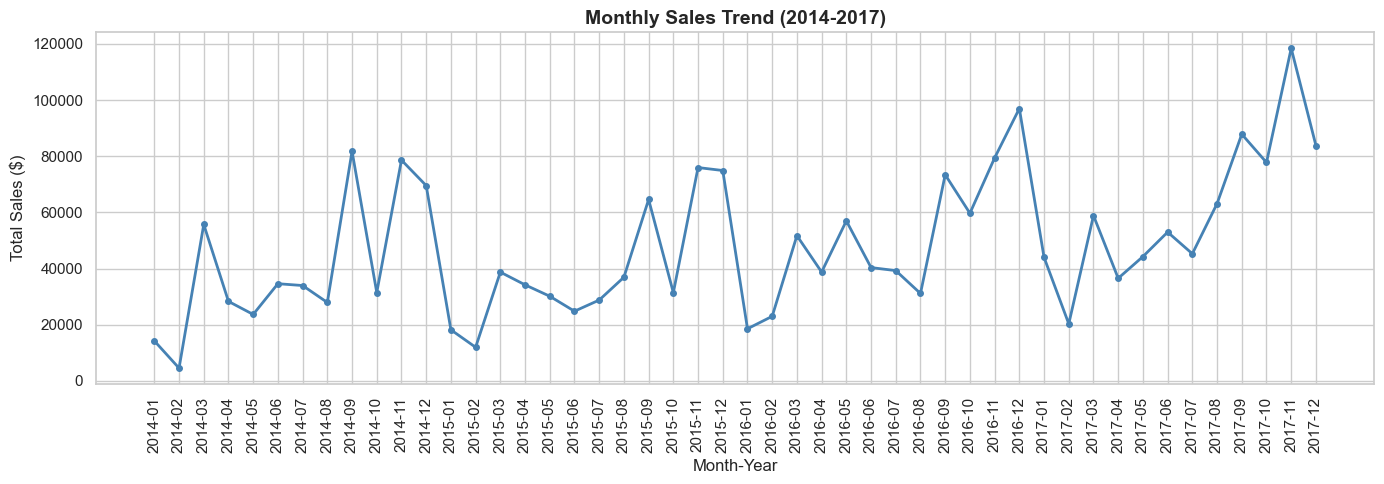

In [8]:
# Aggregating sales by month
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

# Plotting monthly sales trend
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month_Year'], monthly_sales['Sales'], 
         marker='o', color='steelblue', linewidth=2, markersize=4)
plt.xticks(rotation=90)
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

## 6. Category-wise Sales Analysis
Comparing total sales across the three product categories.

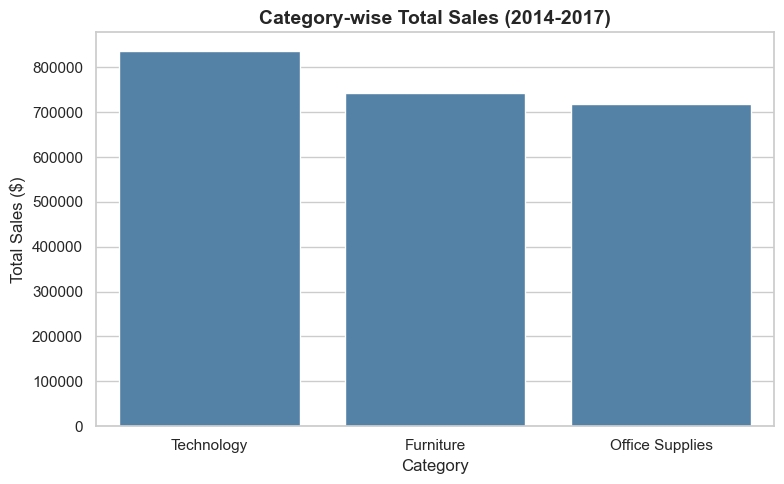

In [9]:
# Category-wise total sales
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values('Sales', ascending=False)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x='Category', y='Sales', color='steelblue')
plt.title('Category-wise Total Sales (2014-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

## 7. Saving Cleaned Data
Saving the cleaned and prepared dataset for use in further analysis.

In [10]:
# Saving cleaned dataframe to CSV
df.to_csv('../data/superstore_cleaned.csv', index=False)

print("✅ Cleaned data saved successfully!")
print("Shape:", df.shape)
print("Columns added: Year, Month, Month_Year")

✅ Cleaned data saved successfully!
Shape: (9994, 24)
Columns added: Year, Month, Month_Year
